## Data prep

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

We then import the data that we will need for our inflation rate forecasting

In [2]:
BSP_CPI = pd.read_csv("/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/raw/bsp_cpibase2018_dataset.csv")
USD_PHP = pd.read_csv("/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/raw/usd_to_php.csv")
Unemployment = pd.read_csv("/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/raw/psa_unemployment_rate.csv")
Crude_Oil = pd.read_csv("/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/raw/global_dubai_crude.csv")
Target_RRP = pd.read_csv("/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/raw/target_rrp.csv")

Inflation rate can be calculated from CPI data

$$
\text{Inflation} = \dfrac{\text{CPI}_{\text{current}} - \text{CPI}_{\text{previous}}}{\text{CPI}_{\text{current}}} \times 100
$$

In [3]:
# CPI / Inflation
BSP_CPI['Date'] = pd.to_datetime(BSP_CPI['Year'].astype(str) + ' ' + BSP_CPI['Month'] + ' 1')
BSP_CPI.rename(columns={'All Items': 'CPI'}, inplace=True)
BSP_CPI = BSP_CPI[['Date', 'CPI']].sort_values('Date')
BSP_CPI['InflationRate'] = BSP_CPI['CPI'].pct_change(12) * 100
BSP_CPI = BSP_CPI[['Date', 'InflationRate']]

# USD/PHP
USD_PHP['Year'] = USD_PHP['Period'].ffill()
USD_PHP['Date'] = pd.to_datetime(USD_PHP['Year'].astype(int).astype(str) + ' ' + USD_PHP['Unnamed: 1'] + ' 1')
USD_PHP = USD_PHP[['Date', 'Average']].rename(columns={'Average': 'USD_PHP'})

# Unemployment
Unemployment['Date'] = pd.to_datetime(Unemployment['Year'].astype(str) + ' ' + Unemployment['Monthly/Quarterly'] + ' 1')
Unemployment['Unemployment Rate'] = pd.to_numeric(Unemployment['Unemployment Rate'], errors='coerce')
Unemployment = Unemployment[['Date', 'Unemployment Rate']].rename(columns={'Unemployment Rate': 'UnemploymentRate'}).sort_values('Date')
Unemployment['UnemploymentRate'] = Unemployment['UnemploymentRate'].ffill(limit_area='inside')

# Dubai crude oil
Crude_Oil['Date'] = pd.to_datetime(Crude_Oil['observation_date'], format='%d/%m/%Y')
Crude_Oil = Crude_Oil[['Date', 'POILDUBUSDM']].rename(columns={'POILDUBUSDM': 'DubaiCrude'})

# Target RRP
Target_RRP['Date'] = pd.to_datetime(Target_RRP['Date'], format='%d/%m/%Y')
Target_RRP['Rate'] = pd.to_numeric(Target_RRP['Rate'], errors='coerce')
Target_RRP = Target_RRP.dropna(subset=['Rate'])
Target_RRP = Target_RRP.sort_values('Date')
Target_RRP = Target_RRP.groupby(pd.Grouper(key='Date', freq='MS')).last().reset_index()
Target_RRP = Target_RRP.rename(columns={'Rate': 'TargetRRP'})
# Merge
INF_data = BSP_CPI.merge(USD_PHP, on='Date', how='outer') \
                  .merge(Unemployment, on='Date', how='outer') \
                  .merge(Crude_Oil, on='Date', how='outer') \
                  .merge(Target_RRP, on='Date', how='outer') \
                  .sort_values('Date') \
                  .reset_index(drop=True)
INF_data.set_index('Date', inplace=True)

start = INF_data['InflationRate'].first_valid_index()
end = INF_data.dropna(how='all').index[-1]
INF_data = INF_data.loc[start:end]

In [4]:
processed_dir = '/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/processed/'
processed_file_path = os.path.join(processed_dir, 'Combined_Macro_Data.csv')

os.makedirs(processed_dir, exist_ok=True)
INF_data.to_csv(processed_file_path, index=True)

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

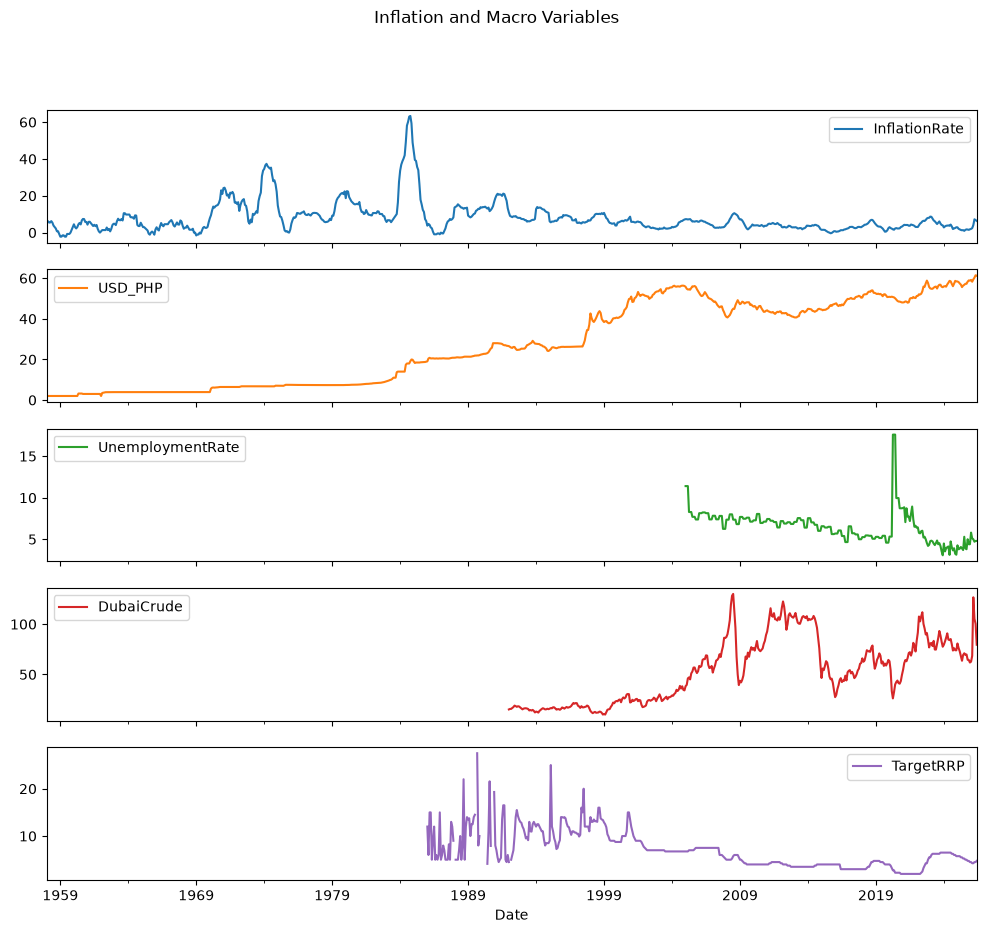

In [5]:
INF_data.plot(subplots=True, figsize=(12, 10), title='Inflation and Macro Variables')

## EDA